# Med Center Shuttle Peak Hours Analysis and Recommendations

This notebook will analyze the APC ridership data to assist in optimizing bus deployment across the med center express shuttle. The analysis will use BusState files from March 2, 2026 - April 17, 2026, this represents 7 weeks worth of data collected M-F.

### Directions

**Inbound:** Carmack 2, 3, 5A and 5B -> University Hospital, Doan Hall

**Outbound:** University Hospital, Doan Hall -> Carmack 2, 3, 5A and 5B

### Key Variables Used
- STOP_ID:      The ID of the stop (401, 403, 404, 94, 95, 401, 37)
- ARRIVAL:      Arrival time of the bus at the current stop
- DEPARTURE:    Departure time of the bus at the current stop
- BOARDINGS:    Number of boardings detected by APC at the current stop 
- ALIGHTINGS:   Number of alightings detected by APC at the current stop
- HOUR:         Hour of event
- MINUTE:       Minute of event
- DATE:         Date of event

In [39]:
# %pip install statsmodels

import sys
import os
import pandas as pd
import numpy as np
import importlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.graphics.mosaicplot import mosaic

# Global config for analysis and viz

# boilerplate for all viz
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F8F6',
    'axes.grid':        True,
    'grid.color':       '#E0DED8',
    'grid.linewidth':   0.6,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

# seaborn styles set
sns.set_style("whitegrid", {
    'axes.facecolor': '#F8F8F6',
    'grid.color':       '#E0DED8',
    'grid.linewidth':   0.6,
})

# stop id and names
STOP_NAMES = {
    37: 'Doan Hall',
    94: 'Carmack 5A',
    95: 'Carmack 5B',
    401: 'University Hospital',
    403: 'Carmack 2',
    404: 'Carmack 3'
}

# bus max capacity
BUS_CAPACITY = 65 # based on previous analysis, 65 is generally considered the max capacity for a cabs bus
BUS_CAPACITY_COMFORT = 50 # this is a guess of what a 'comfortable' capacity may be. Will cross reference with number of seats, etc in future
CARMACK_5_BEGINS = 7 # busses stop at carmack 5 starting after 7am according to run books


---

## Loading and Validation of Data

Input month and year of the targeted month.

- **MONTH:** 3 character abbreviation (ex. MAR)
- **YEAR:** 4 digit number (ex. 2026)

### Note: Raw busstate files will need to be processed in `busstate_processing_pipeline.ipynb` first before running

In [40]:
# go up one level from notebook folder
sys.path.append(os.path.abspath(".."))

from modules import med_center_dashboard as mcd
importlib.reload(mcd)

data_dir = "K:/AP/TTM/Data/WMC_Dashboard/busstate_cleaned"

# month and date dict
MONTH = 'MAR'
YEAR = 2026

# set dir to save cleaned files to 
# repo_dir = "K:/AP/TTM/Data/WMC_Dashboard/analysis_data/peak_hours_cleaned"

df = mcd.process_mc_busstate(year=YEAR, month=MONTH, current_dir=data_dir)

In [41]:
# Cut down df to necessary columns
mc_df = df[['DATE', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS', 'RUN_ID', 'ARRIVAL', 'DEPARTURE', 'DWELL', 'HOUR', 'MINUTE']].copy()
mc_df.columns = mc_df.columns.str.lower()

# map for inbound vs outbound stops
DIRECTION_MAP = {
    37: 'Outbound',
    94: 'Inbound',
    95: 'Inbound',
    401: 'Outbound',
    403: 'Inbound',
    404: 'Inbound'
}

# Parse time-related columns
mc_df['arrival'] = pd.to_datetime(mc_df['arrival'])
mc_df['departure'] = pd.to_datetime(mc_df['departure'])
mc_df['dwell'] = pd.to_timedelta(mc_df['dwell'], unit='s')
mc_df['time'] = pd.to_datetime(mc_df['date'].astype(str) + ' ' + mc_df['arrival'].dt.time.astype(str))

mc_df.sort_values(by='time', inplace=True)

# Normalize numeric dtypes
mc_df['stop_id'] = mc_df['stop_id'].astype(int)
mc_df['boardings'] = mc_df['boardings'].astype(int)
mc_df['alightings'] = mc_df['alightings'].astype(int)
mc_df['run_id'] = mc_df['run_id'].astype(int)

# Add convenience columns
mc_df['stop_name'] = mc_df['stop_id'].map(STOP_NAMES)
mc_df['weekday'] = mc_df['date'].dt.day_name()  # in case weekday-related patterns surface
mc_df['dwell_sec'] = mc_df['dwell'].dt.total_seconds()
mc_df['weekday_num'] = mc_df['date'].dt.weekday  # Monday=0, Sunday=6
mc_df['direction'] = mc_df['stop_id'].map(DIRECTION_MAP)

# Remove weekend rows currently out of scope
mc_df = mc_df[mc_df['weekday'] != 'Saturday']
mc_df = mc_df[mc_df['weekday'] != 'Sunday']

In [6]:
# Shape and data check
print(f'Records : {len(mc_df)}')
print(f'Date range : {mc_df["date"].min().date()}  - {mc_df["date"].max().date()}')
print(f'Unique dates : {mc_df["date"].dt.date.nunique()}')
print(mc_df.dtypes)
mc_df.head(3)

Records : 35769
Date range : 2026-03-02  - 2026-03-31
Unique dates : 22
date            datetime64[us]
stop_id                  int64
boardings                int64
alightings               int64
run_id                   int64
arrival         datetime64[us]
departure       datetime64[us]
dwell          timedelta64[us]
hour                     int32
minute                   int32
time            datetime64[us]
stop_name                  str
weekday                    str
dwell_sec              float64
weekday_num              int32
direction                  str
dtype: object


,date,stop_id,boardings,alightings,run_id,arrival,departure,dwell,hour,minute,time,stop_name,weekday,dwell_sec,weekday_num,direction
16770,2026-03-02,403,0,0,1502,1900-01-01 00:22:07,1900-01-01 00:22:32,0 days 00:00:25,0,22,2026-03-02 00:22:07,Carmack 2,Monday,25.0,0,Inbound
16771,2026-03-02,404,0,0,1502,1900-01-01 00:23:10,1900-01-01 00:23:35,0 days 00:00:25,0,23,2026-03-02 00:23:10,Carmack 3,Monday,25.0,0,Inbound
16772,2026-03-02,94,0,0,1502,1900-01-01 00:24:19,1900-01-01 00:24:26,0 days 00:00:07,0,24,2026-03-02 00:24:19,Carmack 5A,Monday,7.0,0,Inbound


In [7]:
# Missing data check
missing = mc_df.isnull().sum()
missing

date           0
stop_id        0
boardings      0
alightings     0
run_id         0
arrival        0
departure      0
dwell          0
hour           0
minute         0
time           0
stop_name      0
weekday        0
dwell_sec      0
weekday_num    0
direction      0
dtype: int64

In [8]:
# Data ranges and distributions check
mc_df.describe()

,date,stop_id,boardings,alightings,run_id,arrival,departure,dwell,hour,minute,time,dwell_sec,weekday_num
count,35769,35769.000000,35769.000000,35769.000000,35769.000000,35769,35769,35769,35769.000000,35769.000000,35769,35769.000000,35769.000000
mean,2026-03-15 05:51:39.387738,246.953228,3.431295,3.368364,1504.366770,1900-01-01 13:17:14.428500,1900-01-01 13:18:24.926361,0 days 00:01:10.497861,12.792642,29.195560,2026-03-15 19:08:53.816237,70.497861,1.925886
min,2026-03-02 00:00:00,37.000000,0.000000,0.000000,1501.000000,1900-01-01 00:00:00,1900-01-01 00:00:06,0 days 00:00:00,0.000000,0.000000,2026-03-02 00:22:07,0.000000,0.000000
25%,2026-03-09 00:00:00,94.000000,0.000000,0.000000,1502.000000,1900-01-01 07:35:56,1900-01-01 07:37:07,0 days 00:00:35,7.000000,14.000000,2026-03-09 09:18:30,35.000000,1.000000
50%,2026-03-16 00:00:00,401.000000,1.000000,1.000000,1504.000000,1900-01-01 14:11:41,1900-01-01 14:12:39,0 days 00:00:53,14.000000,29.000000,2026-03-16 14:20:00,53.000000,2.000000
75%,2026-03-23 00:00:00,403.000000,5.000000,4.000000,1506.000000,1900-01-01 18:22:19,1900-01-01 18:23:32,0 days 00:01:27,18.000000,44.000000,2026-03-23 17:13:25,87.000000,3.000000
max,2026-03-31 00:00:00,404.000000,51.000000,44.000000,1514.000000,1900-01-01 23:59:55,1900-01-01 23:59:59,0 days 00:22:43,23.000000,59.000000,2026-03-31 00:34:39,1363.000000,4.000000
std,NaN,165.662687,5.516251,5.258505,2.902739,NaN,NaN,0 days 00:00:54.494325,6.108614,17.491757,NaN,54.494326,1.437785



---
## Analysis and Visualization of the Data
**Notes:**
- mc_df denotes the dataframe with the busstate data for the sample of 3/1/2026 - 4/14/2026
- The sample timeframe of 3/1/2026 - 4/14/2026 was chosen due to the new hospital tower opening in late February 2026
    - This should give the best possible view of staffing and demand changes to the shuttle


---

## Key Metrics Summary

In [42]:
# Aggregate to hourly totals
hourly_mc_df = (
    mc_df.groupby('hour')
    .agg(
        total_boardings=('boardings', 'sum'),
        total_alightings=('alightings', 'sum'),
        avg_dwell_sec=('dwell_sec', 'mean')
    )
    .reset_index()
)

# Sanity check of total boardings and alightings
total_boardings = hourly_mc_df['total_boardings'].sum()
total_alightings = hourly_mc_df['total_alightings'].sum()

# Total number of each within 5000
e = total_boardings - total_alightings
print(f'Total boardings: {total_boardings}')
print(f'Total alightings: {total_alightings}')
print(f'Difference: {e}')
# The total boardings and alightings should theoretically be the same
# The difference is likely due to APC data collection error
# Given the large sample size, this small difference should not significantly impact the overall analysis

Total boardings: 122734
Total alightings: 120483
Difference: 2251


In [10]:
# summary stats
peak_hour   = hourly_mc_df.loc[hourly_mc_df['total_boardings'].idxmax(), 'hour']
peak_vol    = hourly_mc_df['total_boardings'].max()
avg_dwell   = hourly_mc_df['avg_dwell_sec'].mean()

peak_hour, peak_vol, avg_dwell

(np.int32(6), np.int64(15879), np.float64(69.71378626547799))


---

### Visualization 1: Total Hourly Boarding Volume

Broad overview to get an idea of the total demand and throughput of the shuttle through an hourly breakdown.

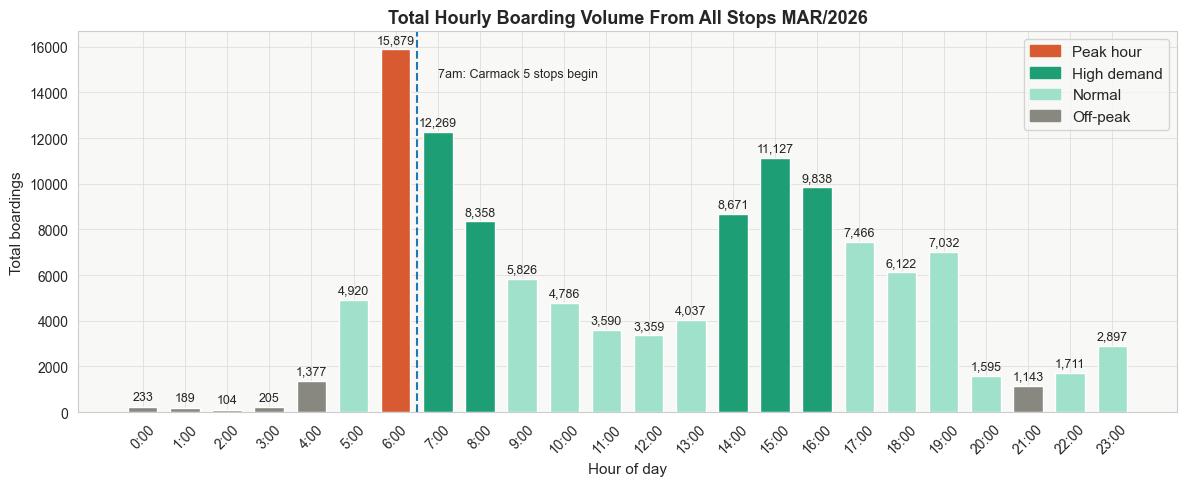

Lower Threshold (25th percentile): 1540.5
Upper Threshold (75th percentile): 7689.0


In [11]:
# Starting at 7am the busses will stop at the carmack stops too.

# define the quartiles for boardings for color coding
q1 = hourly_mc_df['total_boardings'].quantile(0.25)
q3 = hourly_mc_df['total_boardings'].quantile(0.75)

# plot the hourly boardings accross all stops to get a sense of overall traffic

TEAL   = '#1D9E75'       # high demand
GRAY   = '#888780'       # off-peak
CORAL  = '#D85A30'       # peak hour
LIGHT_TEAL   = '#9FE1CB' # 'normal' demand

fig, ax = plt.subplots(figsize=(12, 5))

# define colors for each demand level
def get_color(hour, boardings):
    if hour == peak_hour:
        return CORAL # peak capacity hour
    elif (boardings ) >= q3: # high demand
        return TEAL
    elif boardings <= q1: # low demand
        return GRAY
    return LIGHT_TEAL # normal

colors = [
    get_color(h, b)
    for h, b in zip(hourly_mc_df['hour'], hourly_mc_df['total_boardings'])
]

# x = hour, y =total boardings, color coded by demand
bars = ax.bar(
    hourly_mc_df['hour'],
    hourly_mc_df['total_boardings'],
    color=colors,
    width=0.7
)

# add the value to each bar
max_val = hourly_mc_df['total_boardings'].max()
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max_val * 0.01,
            f'{int(height):,}',
            ha='center',
            va='bottom',
            fontsize=9
        )

# mark time when carmack 5 stops start
ax.axvline(CARMACK_5_BEGINS - 0.5, linestyle='--', linewidth=1.5)

ax.text(
    CARMACK_5_BEGINS,
    max_val * 0.95,
    '7am: Carmack 5 stops begin',
    fontsize=9,
    va='top'
)

# legend
ax.legend(handles=[
    mpatches.Patch(color=CORAL, label='Peak hour'),
    mpatches.Patch(color=TEAL, label='High demand'),
    mpatches.Patch(color=LIGHT_TEAL, label='Normal'),
    mpatches.Patch(color=GRAY, label='Off-peak')
])

# format axes
ax.set(
    xticks=hourly_mc_df['hour'],
    xticklabels=[f'{h}:00' for h in hourly_mc_df['hour']],
    xlabel='Hour of day',
    ylabel='Total boardings',
    title=f'Total Hourly Boarding Volume From All Stops {MONTH}/{YEAR}'
)
# make easier to see
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig(f'1_total_hourly_boardings_all_stops_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Lower Threshold (25th percentile): {q1}')
print(f'Upper Threshold (75th percentile): {q3}')

### **Interpretation:**

Peak hourly boarding volume is within the 0600 hour. This makes sense with a moderately standardized 0700 shift start. This peak is followed by 2 more hours of high demand until leveling out at 0900. Afternoon peak is less concentrated and begins in the 1400 hour and does not reach 'off peak' until 2100. 


---

### Visualization 2: Day of Week Patterns

Determine if there is a difference in demand for specific days of the week

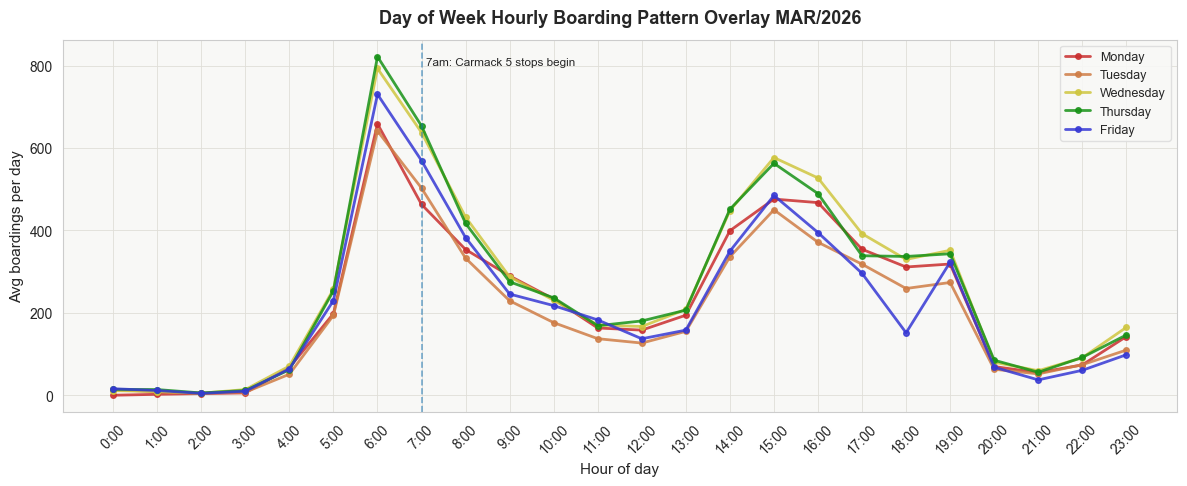

In [12]:
# set order and colors for days
colors = {
    'Monday': '#C92E2E',
    'Tuesday': '#CF7D46',
    'Wednesday': '#CFC640',
    'Thursday': '#179217',
    'Friday': '#3638D4'
}
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# Subset data into hourly boardings by day of week
hourly_by_day = (
    mc_df[mc_df['weekday'].isin(day_order)]
    .groupby(['weekday', 'weekday_num', 'hour'])['boardings']
    .sum()
    .reset_index()
    .sort_values(['weekday_num', 'hour'])
)

# Normalize to per-occurrence average (divide by number of each weekday in sample)
day_counts = mc_df.groupby('weekday')['date'].apply(lambda x: x.dt.date.nunique())
hourly_by_day['avg_boardings'] = hourly_by_day.apply(
    lambda r: r['boardings'] / day_counts.get(r['weekday'], 1), axis=1
)

fig, ax = plt.subplots(figsize=(12, 5))

for day in day_order:
    subset = hourly_by_day[(hourly_by_day['weekday'] == day)]
    color = colors[day]

    ax.plot(subset['hour'], subset['avg_boardings'], marker='o', markersize=4, linewidth=2, color=color, label=day, alpha=0.85)

# Indicate when carmack 5 stops begin
ax.axvline(x=CARMACK_5_BEGINS, linewidth=1.2,
           linestyle='--', alpha=0.6)
ax.text(CARMACK_5_BEGINS + 0.1, ax.get_ylim()[1] * 0.95,
        '7am: Carmack 5 stops begin', fontsize=8.5, va='top')

ax.set_xticks(range(hourly_by_day['hour'].min(), hourly_by_day['hour'].max() + 1))
ax.set_xticklabels([f'{h}:00' for h in range(hourly_by_day['hour'].min(), hourly_by_day['hour'].max() + 1)],
                    rotation=45)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg boardings per day')
ax.set_title(f'Day of Week Hourly Boarding Pattern Overlay {MONTH}/{YEAR}', pad=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='#ddd')

plt.tight_layout()
# plt.savefig(f'2_hourly_boardings_by_day_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

### **Interpretation**

The days of the week have generally the same curve. The morning hour has a clear steep peak at 0600. Afternoon peak is visivle again, peaking at 1500 with a more shallow descent until the 2000 hour. There is a statistically significant drop in boardings at the 1800 hour for Fridays. This is likely due to on site parking opening up for weekend staffing at this time. Due to staffing strategy and since the demand "peaks" again at 1900 to match the other days, my recommendation would be to not consider this in staffing the shuttle. 


---

## Visualization 3: Stop by Stop Boarding

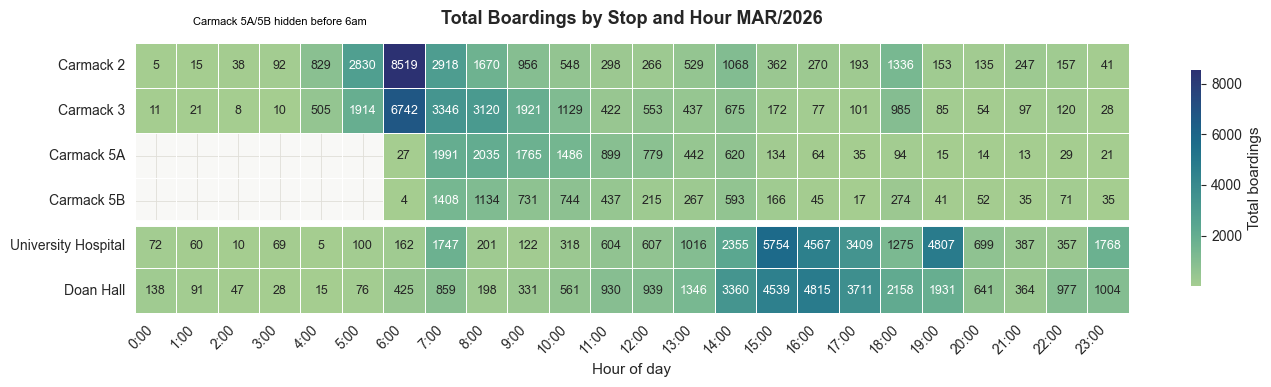

In [13]:
# create a df with hourly boardings by stop
hourly_by_stop = (
    mc_df.groupby(['stop_name', 'hour'])['boardings']
    .sum()
    .reset_index()
    .astype({'boardings': float})
 )

# Hide Carmack 5A/5B cells before 6am in the heatmap
hide_mask = hourly_by_stop['stop_name'].isin(['Carmack 5A', 'Carmack 5B']) & (hourly_by_stop['hour'] < 6)
hourly_by_stop.loc[hide_mask, 'boardings'] = np.nan

# order the stops
stops_order = ['Carmack 2', 'Carmack 3', 'Carmack 5A', 'Carmack 5B', 'University Hospital', 'Doan Hall'] 

pivot = (
    hourly_by_stop
    .pivot(index='stop_name', columns='hour', values='boardings')
    .reindex(stops_order)
)
mask = pivot.isna()

fig, ax = plt.subplots(figsize=(14, 4))

sns.heatmap(
    pivot,
    ax=ax,
    cmap='crest',
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.0f', 
    annot_kws={'size': 9},
    cbar_kws={'label': 'Total boardings', 'shrink': 0.8},
    mask=mask
)

# Draw divider between parking and med-center rows
parking_rows = sum(1 for r in stops_order if 'Carmack' in r and r in hourly_by_stop['stop_name'].unique())
ax.axhline(y=parking_rows, color='white', linewidth=5)

ax.text(3.5, -0.4, 'Carmack 5A/5B hidden before 6am', ha='center', fontsize=8, color='black', zorder=6)

ax.set_xticklabels([f'{h}:00' for h in pivot.columns], rotation=45, ha='right')
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
ax.set_title(f'Total Boardings by Stop and Hour {MONTH}/{YEAR}', pad=14)

plt.tight_layout()
# plt.savefig(f'3_hourly_boardings_by_stop_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

### **Interpretation:**

- 9am hour drops to 3 busses. 
- 


---

## Visualization 3a: Mosaic Plot of Stop Traffic

c:\Users\morgan.1461\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\graphics\mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


(<Figure size 640x480 with 3 Axes>,
 {('Inbound', 'Carmack 2'): (0.0,
   np.float64(0.0),
   0.5014750534952521,
   np.float64(0.3505600997148728)),
  ('Inbound', 'Carmack 3'): (0.0,
   np.float64(0.36306009971487274),
   0.5014750534952521,
   np.float64(0.33649289571353486)),
  ('Inbound', 'Carmack 5A'): (0.0,
   np.float64(0.7120529954284076),
   0.5014750534952521,
   np.float64(0.1564117778237946)),
  ('Inbound', 'Carmack 5B'): (0.0,
   np.float64(0.8809647732522022),
   0.5014750534952521,
   np.float64(0.09403522674779778)),
  ('Inbound', 'Doan Hall'): (0.0,
   np.float64(0.9874999999999999),
   0.5014750534952521,
   np.float64(0.0)),
  ('Inbound', 'University Hospital'): (0.0,
   np.float64(1.0),
   0.5014750534952521,
   np.float64(0.0)),
  ('Outbound', 'Carmack 2'): (0.5210828966325071,
   np.float64(0.0),
   0.47891710336749294,
   np.float64(0.0)),
  ('Outbound', 'Carmack 3'): (0.5210828966325071,
   np.float64(0.012499999999999999),
   0.47891710336749294,
   np.float64(0

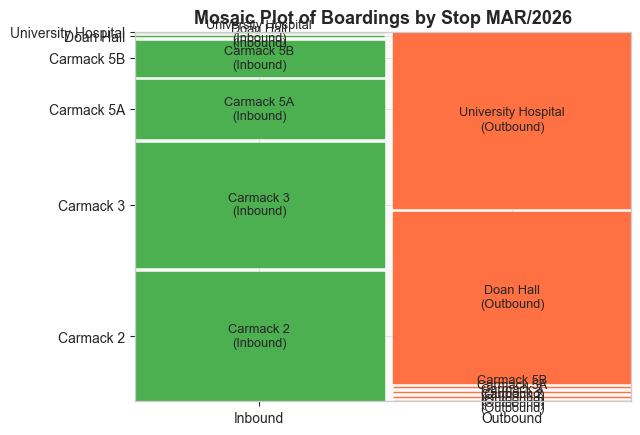

In [14]:
# no seaborn for mosaic plots
# build direction labels so inbound/outbound stops are their own rows
from statsmodels.graphics.mosaicplot import mosaic

mosaic_mc_df = (
    mc_df.groupby(['direction', 'stop_name'], observed=True)['boardings']
    .sum()
    .reset_index()
)

inbound_stops = [
    'Carmack 2',
    'Carmack 3',
    'Carmack 5A',
    'Carmack 5B'
]

outbound_stops = [
    'University Hospital',
    'Doan Hall'
]

mosaic_mc_df = mc_df[
    ((mc_df['direction'] == 'Inbound') & (mc_df['stop_name'].isin(inbound_stops))) |
    ((mc_df['direction'] == 'Outbound') & (mc_df['stop_name'].isin(outbound_stops)))
].groupby(['direction', 'stop_name'], observed=True)['boardings'].sum().reset_index()

mosaic_mc_df = mosaic_mc_df.sort_values(['direction', 'stop_name'])

mosaic_data = (
    mosaic_mc_df
    .set_index(['direction', 'stop_name'])['boardings']
    .to_dict()
)

# control function over formatting
def labelizer(key):
    direction, stop = key
    return f'{stop}\n({direction})'

def props(key):
    direction, stop = key
    return {
        'color': '#4CAF50' if direction == 'Inbound' else '#FF7043',
        'edgecolor': 'white'
    }

mosaic(
    mosaic_data,
    labelizer=labelizer,
    properties=props,
    title=f'Mosaic Plot of Boardings by Stop {MONTH}/{YEAR}',
    gap=0.02
)



---

## Visualization 4: Boarding Direction Split

In [15]:
# Bus load metric: average boardings per completed trip, split inbound vs outbound
# BUS_CAPACITY_COMFORT is the comfortable threshold of 50 passengers on a bus.

# inbound vs outbound stops
# inbound: all carmack
INBOUND_STOPS = {
    'Carmack 2': 403,
    'Carmack 3': 404,
    'Carmack 5A': 94,
    'Carmack 5B': 95
}

# outbound: doan and uh
OUTBOUND_STOPS = {
    'Doan Hall': 37,
    'University Hospital': 401
}

# stop_id lookup
inbound_ids = set(INBOUND_STOPS.values())
outbound_ids = set(OUTBOUND_STOPS.values())
expected_stop_counts = {
    'Inbound': len(inbound_ids),
    'Outbound': len(outbound_ids)
}

trip_events = (
    mc_df[mc_df['stop_id'].isin(inbound_ids | outbound_ids)]
    .sort_values(['date', 'run_id', 'time', 'stop_id'])
    .copy()
)

trip_events['direction'] = trip_events['stop_id'].apply(
    lambda s: 'Inbound' if s in inbound_ids else 'Outbound'
)

# Stop-level metric: average boardings contributed by each bus at each stop within each hour.
per_stop_hour = (
    trip_events.groupby(['date', 'run_id', 'stop_id', 'direction', 'hour'], as_index=False)
    .agg(total_boardings=('boardings', 'sum'))
)

avg_boardings_per_bus = (
    per_stop_hour.groupby(['stop_id', 'direction', 'hour'], as_index=False)
    .agg(
        avg_boardings_per_bus=('total_boardings', 'mean'),
        n_observations=('total_boardings', 'count')
    )
    .sort_values(['direction', 'stop_id', 'hour'])
)

def assign_trip_ids(group):
    group = group.sort_values(['time', 'stop_id']).copy()
    trip_number = 0
    seen_stops = set()
    trip_ids = []

    for stop_id in group['stop_id']:
        if stop_id in seen_stops:
            trip_number += 1
            seen_stops = set()
        trip_ids.append(trip_number)
        seen_stops.add(stop_id)

    group['trip_id'] = trip_ids
    return group

# Build actual trip units across the full ordered run, not inside hour buckets.
trip_groups = []
for (date, run_id, direction), group in trip_events.groupby(['date', 'run_id', 'direction'], sort=False):
    group = assign_trip_ids(group)
    group['date'] = date
    group['run_id'] = run_id
    group['direction'] = direction
    trip_groups.append(group)

trip_events = pd.concat(trip_groups, ignore_index=True)

ib_ob_trip_boardings = (
    trip_events.groupby(['date', 'run_id', 'direction', 'trip_id'], as_index=False)
    .agg(
        trip_start=('time', 'min'),
        trip_end=('time', 'max'),
        total_trip_boardings=('boardings', 'sum'),
        stop_visits=('stop_id', 'count'),
        unique_stop_count=('stop_id', 'nunique')
    )
    .assign(
        expected_stop_count=lambda d: d['direction'].map(expected_stop_counts),
        is_complete_trip=lambda d: d['unique_stop_count'] == d['expected_stop_count'],
        hour=lambda d: d['trip_end'].dt.hour
    )
)

completed_trips = ib_ob_trip_boardings[ib_ob_trip_boardings['is_complete_trip']].copy()

direction_hourly = (
    completed_trips.groupby(['direction', 'hour'], as_index=False)
    .agg(
        avg_direction_boardings_per_trip=('total_trip_boardings', 'mean'),
        trips_observed=('trip_id', 'count')
    )
    .assign(
        percent_of_capacity=lambda d: (d['avg_direction_boardings_per_trip'] / BUS_CAPACITY_COMFORT) * 100
    )
    .sort_values(['direction', 'hour'])
)

print(f'Completed trips retained: {len(completed_trips):,} of {len(ib_ob_trip_boardings):,}')
#display(direction_hourly)
print(f'Max completed-trip boardings: {completed_trips["total_trip_boardings"].max()}')
#display(completed_trips.nlargest(5, 'total_trip_boardings'))

Completed trips retained: 11,336 of 12,780
Max completed-trip boardings: 75


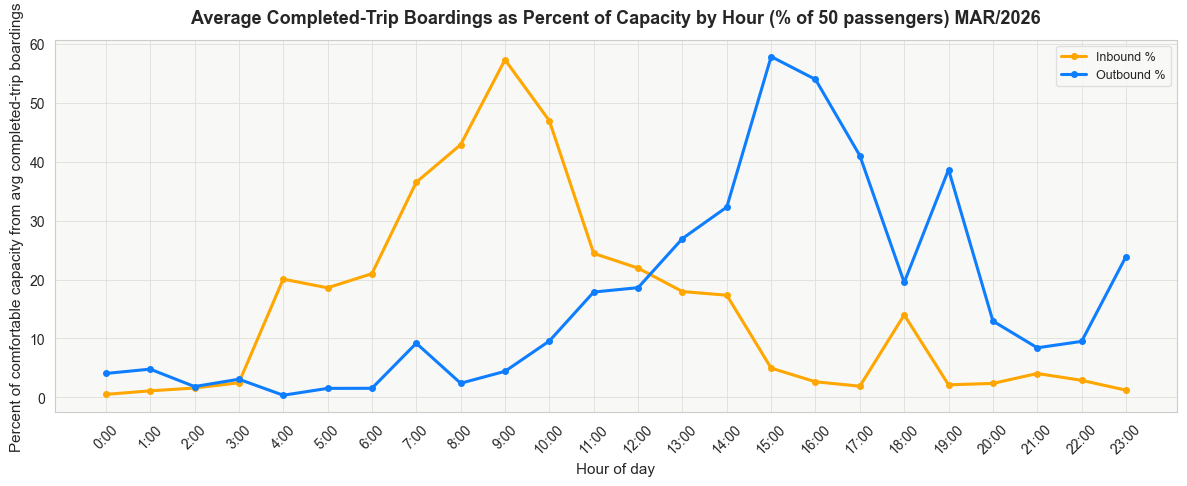

In [17]:
# viz
fig, ax = plt.subplots(figsize=(12, 5))

for direction, line_color in [('Inbound', "#ffa600"), ('Outbound', "#0e7eff")]:
    subset = direction_hourly[direction_hourly['direction'] == direction]
    ax.plot(
        subset['hour'],
        subset['percent_of_capacity'],
        marker='o',
        markersize=4,
        linewidth=2.2,
        color=line_color,
        label=f'{direction} %'
    )

ax.set_xticks(range(direction_hourly['hour'].min(), direction_hourly['hour'].max() + 1))
ax.set_xticklabels([f'{h}:00' for h in range(direction_hourly['hour'].min(), direction_hourly['hour'].max() + 1)],
                    rotation=45)

ax.set_xlabel('Hour of day')
ax.set_ylabel('Percent of comfortable capacity from avg completed-trip boardings')
ax.set_title(f'Average Completed-Trip Boardings as Percent of Capacity by Hour (% of 50 passengers) {MONTH}/{YEAR}', pad=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='#ddd')

plt.tight_layout()
# plt.savefig(f'4_average_completed_trip_boardings_percent_capacity_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

# direction_hourly

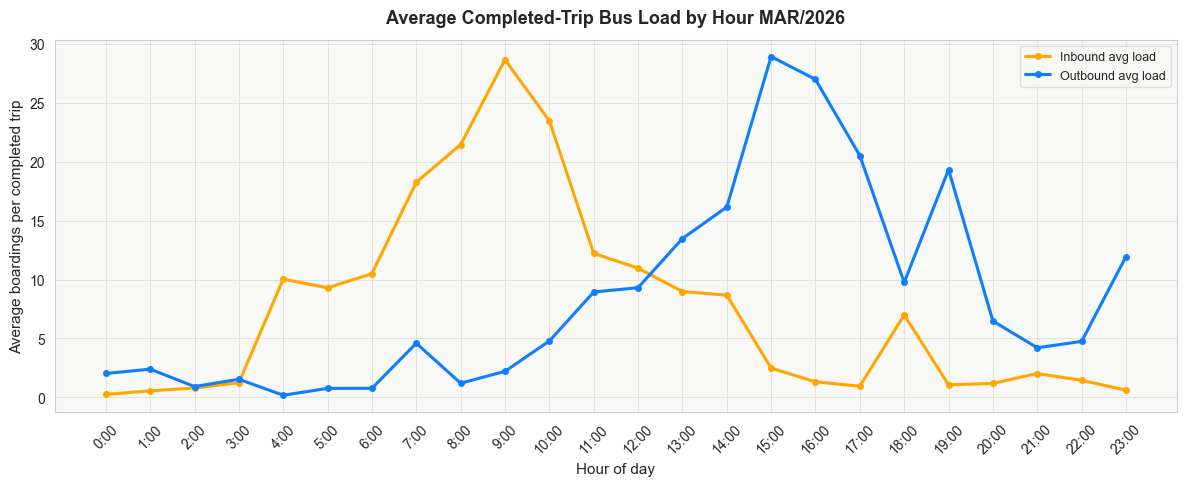

In [18]:
# viz: same trend plot, using average bus load (boardings per completed trip) instead of % capacity
fig, ax = plt.subplots(figsize=(12, 5))

for direction, line_color in [('Inbound', "#ffa600"), ('Outbound', "#0e7eff")]:
    subset = direction_hourly[direction_hourly['direction'] == direction]
    ax.plot(
        subset['hour'],
        subset['avg_direction_boardings_per_trip'],
        marker='o',
        markersize=4,
        linewidth=2.2,
        color=line_color,
        label=f'{direction} avg load'
    )

ax.set_xticks(range(direction_hourly['hour'].min(), direction_hourly['hour'].max() + 1))
ax.set_xticklabels(
    [f'{h}:00' for h in range(direction_hourly['hour'].min(), direction_hourly['hour'].max() + 1)],
    rotation=45
)

ax.set_xlabel('Hour of day')
ax.set_ylabel('Average boardings per completed trip')
ax.set_title(f'Average Completed-Trip Bus Load by Hour {MONTH}/{YEAR}', pad=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='#ddd')

plt.tight_layout()
plt.show()

,date,stop_id,boardings,alightings,run_id,arrival,departure,dwell,hour,minute,time,stop_name,weekday,dwell_sec,weekday_num,direction
16770,2026-03-02,403,0,0,1502,1900-01-01 00:22:07,1900-01-01 00:22:32,0 days 00:00:25,0,22,2026-03-02 00:22:07,Carmack 2,Monday,25.0,0,Inbound
16771,2026-03-02,404,0,0,1502,1900-01-01 00:23:10,1900-01-01 00:23:35,0 days 00:00:25,0,23,2026-03-02 00:23:10,Carmack 3,Monday,25.0,0,Inbound
16772,2026-03-02,94,0,0,1502,1900-01-01 00:24:19,1900-01-01 00:24:26,0 days 00:00:07,0,24,2026-03-02 00:24:19,Carmack 5A,Monday,7.0,0,Inbound
16773,2026-03-02,95,0,0,1502,1900-01-01 00:25:02,1900-01-01 00:26:20,0 days 00:01:18,0,25,2026-03-02 00:25:02,Carmack 5B,Monday,78.0,0,Inbound
16774,2026-03-02,94,0,0,1502,1900-01-01 00:26:50,1900-01-01 00:26:50,0 days 00:00:00,0,26,2026-03-02 00:26:50,Carmack 5A,Monday,0.0,0,Inbound
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19479,2026-03-31,401,1,0,1503,1900-01-01 00:22:05,1900-01-01 00:23:06,0 days 00:01:01,0,22,2026-03-31 00:22:05,University Hospital,Tuesday,61.0,1,Outbound
19480,2026-03-31,37,1,0,1503,1900-01-01 00:23:26,1900-01-01 00:25:32,0 days 00:02:06,0,23,2026-03-31 00:23:26,Doan Hall,Tuesday,126.0,1,Outbound
19481,2026-03-31,403,0,0,1503,1900-01-01 00:31:37,1900-01-01 00:31:52,0 days 00:00:15,0,31,2026-03-31 00:31:37,Carmack 2,Tuesday,15.0,1,Inbound
19482,2026-03-31,404,0,1,1503,1900-01-01 00:33:06,1900-01-01 00:33:35,0 days 00:00:29,0,33,2026-03-31 00:33:06,Carmack 3,Tuesday,29.0,1,Inbound


Text(0.5, 1.0, 'Unique Runs Observed by Hour')

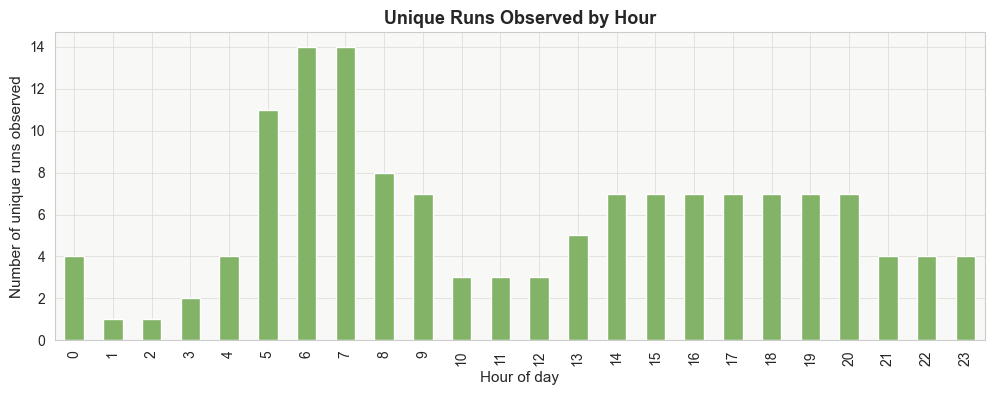

In [19]:
# find the number of unique runs observed in each hour
display(mc_df)

bus_counts = (
    mc_df.groupby('hour')['run_id']
    .nunique()
    .reindex(range(24), fill_value=0)
)

bus_counts.plot(kind='bar', color='#82b366', figsize=(12, 4))
plt.xlabel('Hour of day')
plt.ylabel('Number of unique runs observed')
plt.title('Unique Runs Observed by Hour')



---

## Visualization 5: Recommended Buses Per Hour

Goal is a model predicting how many busses should be run per hour to handle the capacity at each timeframe

In [43]:
# constants
IDEAL_CAPACITY = 50 # what is a 'comfortable' load
MAX_CAPACITY = 65 # over 65 passengers is considered overcapacity
FULL_LOOP_TIME_MIN = 20
CURRENT_HEADWAY_TARGETS = { # from headway targets in monthly dashboard
    0: 20, # 12am
    1: 20, # 1am
    2: 20, # 2am
    3: 20, # 3am
    4: 20, # 4am
    5: 10, # 5am
    6: 3, # 6am
    7: 3, # 7am
    8: 10, # 8am
    9: 10, # 9am
    10: 10, # 10am
    11: 10, # 11am
    12: 10, # 12pm
    13: 10, # 1pm
    14: 5, # 2pm
    15: 5, # 3pm
    16: 3, # 4pm
    17: 3, # 5pm
    18: 5, # 6pm
    19: 5, # 7pm
    20: 10, # 8pm
    21: 10, # 9pm
    22: 5, # 10pm
    23: 5 # 11pm
}

# Passenger demand is generally very consistent from day to day
# hourly_mc_df

### XGBoost Model for Predicting Bus Demand per Hour

This model is a machine learning ttechnique that uses gradient boosted decision trees. 

In [59]:
#%pip install xgboost scikit-learn

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [67]:
hourly_mc_df  # base table used for bus recommendation modeling

# Convert sampled totals into a typical service-day hourly demand.
service_days = mc_df["date"].dt.date.nunique()
hourly_mc_df["avg_boardings_per_day"] = hourly_mc_df["total_boardings"] / service_days

# Estimate hourly carrying capacity per bus from loop time.
trips_per_bus_per_hour = max(1, int(round(60 / FULL_LOOP_TIME_MIN)))
passengers_per_bus_per_hour = IDEAL_CAPACITY * trips_per_bus_per_hour

# Volume-based recommendation (kept for comparison).
hourly_mc_df["volume_buses_needed"] = np.ceil(
    hourly_mc_df["avg_boardings_per_day"] / passengers_per_bus_per_hour
).astype(int)
hourly_mc_df["volume_buses_needed"] = hourly_mc_df["volume_buses_needed"].clip(lower=1)

# Observed reality: buses in service by hour = unique run_id count in that hour.
observed_buses_by_hour = (
    mc_df.groupby("hour")["run_id"]
    .nunique()
    .reindex(hourly_mc_df["hour"], fill_value=0)
    .astype(int)
    .values
)
hourly_mc_df["observed_buses"] = observed_buses_by_hour

# Use observed buses as the target requested.
hourly_mc_df["buses_needed"] = hourly_mc_df["observed_buses"]

# Time structure is cyclical - 11pm and 12am are adjacent.
hourly_mc_df["hour_sin"] = np.sin(2 * np.pi * hourly_mc_df["hour"] / 24)
hourly_mc_df["hour_cos"] = np.cos(2 * np.pi * hourly_mc_df["hour"] / 24)

# Additional predictors from observed operations.
hourly_mc_df["net_flow"] = hourly_mc_df["total_boardings"] - hourly_mc_df["total_alightings"]
hourly_mc_df["flow_ratio"] = hourly_mc_df["total_boardings"] / (hourly_mc_df["total_alightings"] + 1)
hourly_mc_df["dwell_log"] = np.log1p(hourly_mc_df["avg_dwell_sec"])

features = [
    "avg_boardings_per_day",
    "total_alightings",
    "avg_dwell_sec",
    "hour_sin",
    "hour_cos",
    "net_flow",
    "flow_ratio",
    "dwell_log"
 ]

X = hourly_mc_df[features]
y = hourly_mc_df["buses_needed"]

In [69]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X, y)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [74]:
hourly_mc_df["pred_buses_needed"] = np.ceil(model.predict(X)).astype(int)
hourly_mc_df["pred_buses_needed"] = hourly_mc_df["pred_buses_needed"].clip(lower=1)

hourly_mc_df[[
    "hour",
    "avg_boardings_per_day",
    "observed_buses",
    "pred_buses_needed"
 ]].sort_values("hour")

,hour,avg_boardings_per_day,observed_buses,pred_buses_needed
0,0,10.590909,4,4
1,1,8.590909,1,1
2,2,4.727273,1,2
3,3,9.318182,2,3
4,4,62.590909,4,5
5,5,223.636364,11,11
6,6,721.772727,14,15
7,7,557.681818,14,14
8,8,379.909091,8,9
9,9,264.818182,7,7


**Interpretation:**

The observed busses col is the actual amount of observed busses given the hour. The model is capturing the current operating pattern well, but is quite overkill


---

## Visualization 6: Final Recommendations

Current Headway Targets (4/21/2026):
| **Time Period** | **Target Headway** (minutes) | Notes:                       |
|-----------------|------------------------------|------------------------------|
| 0000 - 0500     | 20                           | 1 bus running                |
| 0500 - 0600     | 10                           |                              |
| 0600 - 0800     | 3                            | Current peak morning hours   |
| 0800 - 1400     | 10                           |                              |
| 1400 - 2000     | 5                            | Current peak afternoon hours |
| 2000 - 2200     | 10                           |                              |
| 2200 - 0000     | 5                            | "Second" afternoon peak      |